# Notebook 05: Where a Standard PINN Struggles — Low-Viscosity Burgers

This notebook repeats the viscous Burgers setup with a much smaller viscosity. The resulting sharp fronts make the problem considerably harder for a standard PINN with a smooth MLP.


## Why this is an honest failure case

- We keep a standard PINN architecture and train it fairly.
- The low-viscosity regime develops steep gradients that challenge smooth neural approximators.
- This illustrates spectral bias and the difficulty standard PINNs have with sharp, multiscale structure.


In [1]:
from pathlib import Path
import sys
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.integrate import solve_bvp, solve_ivp
from scipy.interpolate import RegularGridInterpolator
from tqdm.auto import trange


ROOT = Path(r"e:/Optimal_Control/PINN/hjb_pinn_exoskeleton")
if not ROOT.exists():
    ROOT = Path.cwd().resolve()
    if ROOT.name == "notebooks":
        ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.utils import set_global_seed, get_device

set_global_seed(42)
device = get_device()
plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams["figure.dpi"] = 140
NOTEBOOK_NAME = "05_pinn_failure_low_viscosity_burgers"
OUTDIR = ROOT / "notebooks" / "debug_outputs" / NOTEBOOK_NAME
OUTDIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name: str):
    fig.tight_layout()
    fig.savefig(OUTDIR / name, bbox_inches="tight")

print("device:", device)

device: cpu


c:\Users\Mohammad Belal\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
NU_LOW = 0.003
T_FINAL = 1.0
NX = 301
X = np.linspace(-1.0, 1.0, NX)
DX = X[1] - X[0]
DT = 5e-4
NT = int(T_FINAL / DT) + 1
T_EVAL = np.linspace(0.0, T_FINAL, NT)

def burgers_initial(x):
    return -np.sin(np.pi * x)

u_ref = np.zeros((NT, NX), dtype=np.float64)
u_ref[0] = burgers_initial(X)
for n in range(NT - 1):
    u = u_ref[n]
    f = 0.5 * u ** 2
    wave_speed = np.maximum(np.abs(u[:-1]), np.abs(u[1:]))
    flux_half = 0.5 * (f[:-1] + f[1:]) - 0.5 * wave_speed * (u[1:] - u[:-1])
    diffusion = NU_LOW * (u[2:] - 2.0 * u[1:-1] + u[:-2]) / (DX ** 2)

    u_next = u.copy()
    u_next[1:-1] = u[1:-1] - (DT / DX) * (flux_half[1:] - flux_half[:-1]) + DT * diffusion
    u_next[0] = 0.0
    u_next[-1] = 0.0
    u_ref[n + 1] = u_next

class VanillaBurgersPINN(nn.Module):
    def __init__(self, hidden_width=64, hidden_depth=4):
        super().__init__()
        layers = [nn.Linear(2, hidden_width), nn.Tanh()]
        for _ in range(hidden_depth - 1):
            layers += [nn.Linear(hidden_width, hidden_width), nn.Tanh()]
        layers.append(nn.Linear(hidden_width, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

def burgers_terms(model, x, t):
    u = model(x, t)
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    residual = u_t + u * u_x - NU_LOW * u_xx
    return u, residual

## Train the standard PINN fairly

We use the same style of architecture as the inverse Burgers notebook. The point is not to sabotage the method; the point is to observe what happens when the solution contains steep fronts.


In [3]:
model = VanillaBurgersPINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 3000
history = {"total": [], "physics": [], "bc_ic": []}

for epoch in trange(epochs, desc="Training low-viscosity Burgers PINN"):
    optimizer.zero_grad()

    x_f = -1.0 + 2.0 * torch.rand(5000, 1, device=device, requires_grad=True)
    t_f = T_FINAL * torch.rand(5000, 1, device=device, requires_grad=True)
    _, residual = burgers_terms(model, x_f, t_f)
    loss_physics = (residual ** 2).mean()

    t_bc = T_FINAL * torch.rand(400, 1, device=device)
    x_left = -torch.ones_like(t_bc)
    x_right = torch.ones_like(t_bc)
    loss_bc = (model(x_left, t_bc) ** 2).mean() + (model(x_right, t_bc) ** 2).mean()

    x_ic = -1.0 + 2.0 * torch.rand(400, 1, device=device)
    t_ic = torch.zeros_like(x_ic)
    u_ic_target = torch.tensor(burgers_initial(x_ic.detach().cpu().numpy()), dtype=torch.float32, device=device)
    loss_ic = ((model(x_ic, t_ic) - u_ic_target) ** 2).mean()

    loss_bc_ic = loss_bc + loss_ic
    loss = loss_physics + 10.0 * loss_bc_ic
    loss.backward()
    optimizer.step()

    history["total"].append(float(loss.detach().cpu()))
    history["physics"].append(float(loss_physics.detach().cpu()))
    history["bc_ic"].append(float(loss_bc_ic.detach().cpu()))

Training low-viscosity Burgers PINN: 100%|██████████| 3000/3000 [00:55<00:00, 53.86it/s]


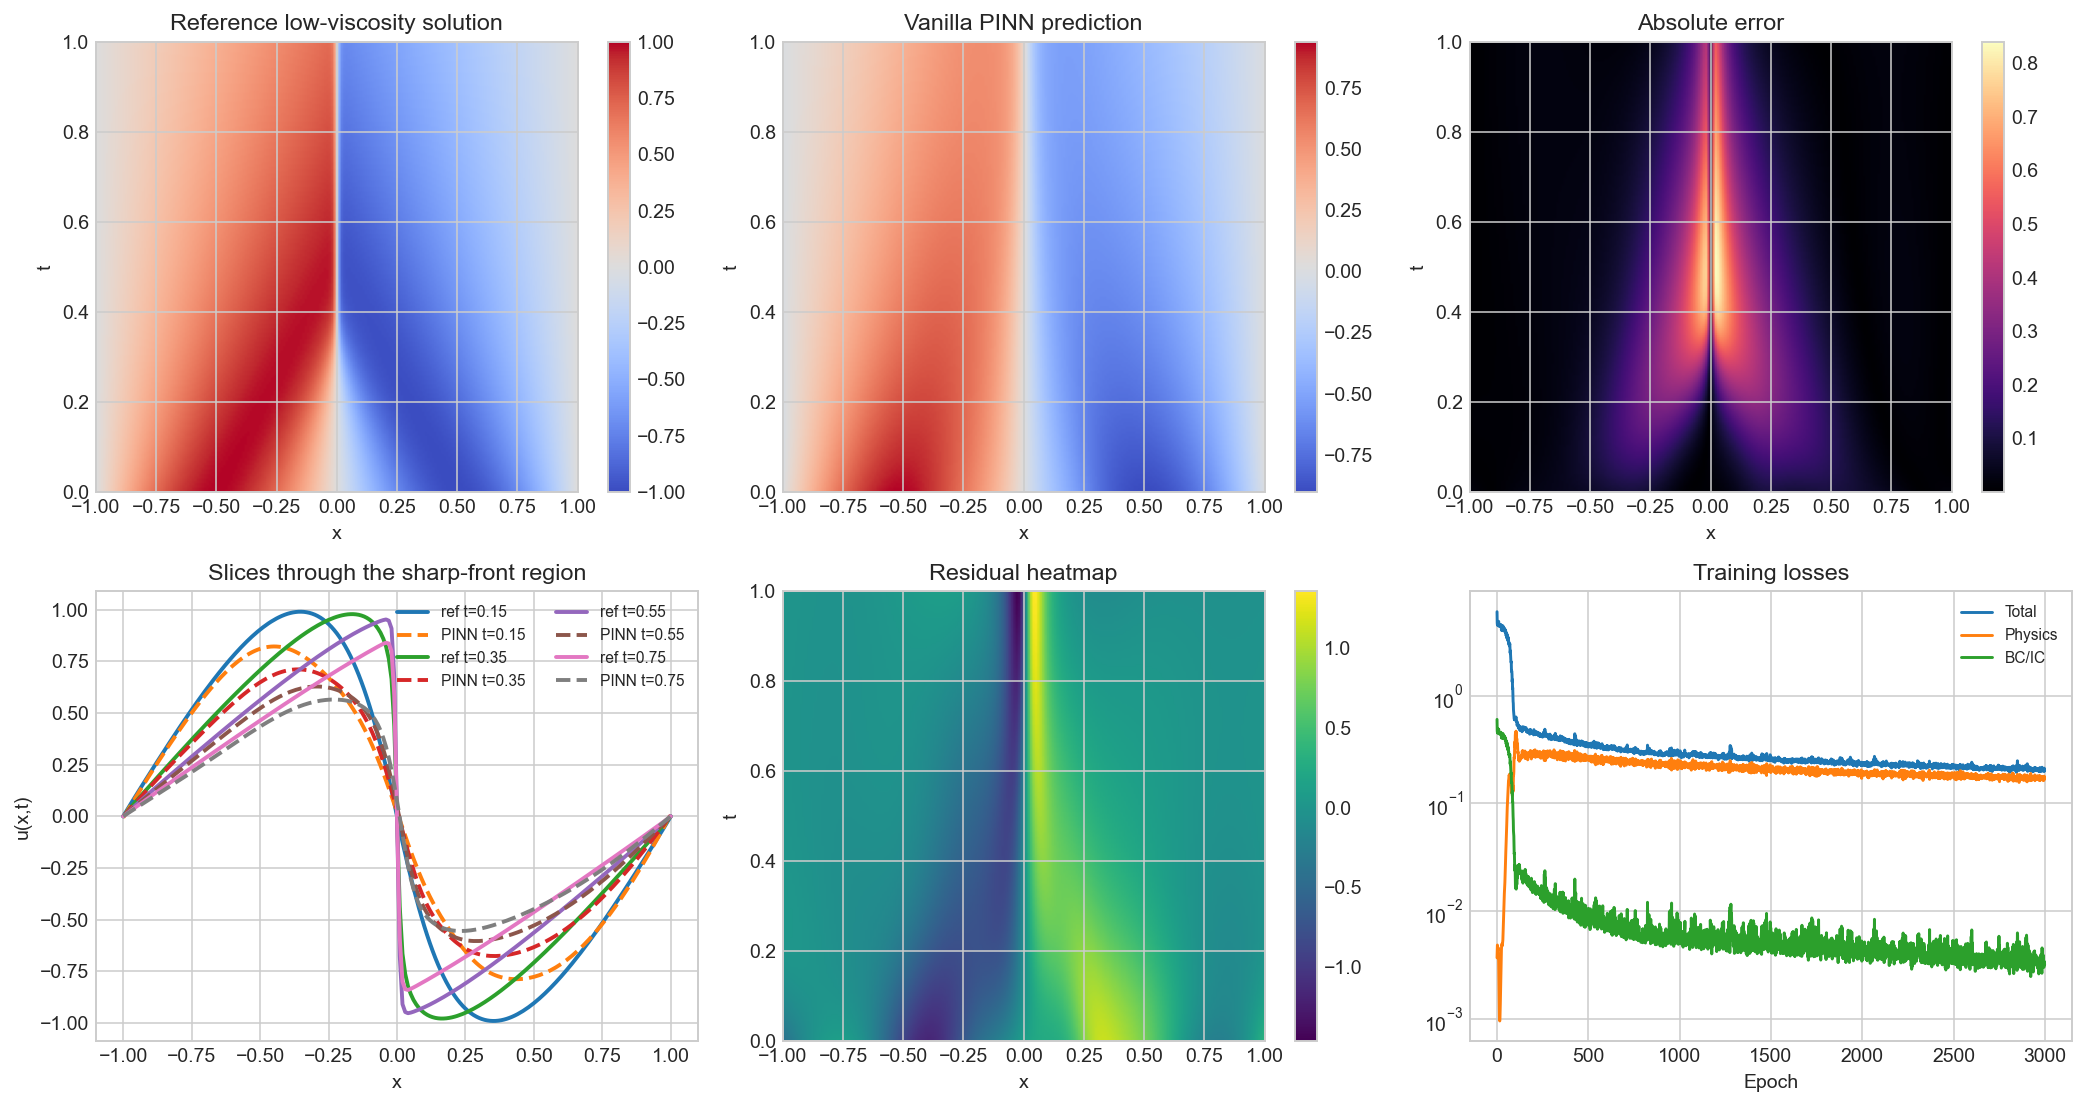

Mean absolute field error: 1.146e-01
Max absolute field error: 8.400e-01


In [4]:
x_plot = np.linspace(-1.0, 1.0, 201)
t_plot = np.linspace(0.0, T_FINAL, 201)
XX, TT = np.meshgrid(x_plot, t_plot)
with torch.no_grad():
    x_tensor = torch.tensor(XX.reshape(-1, 1), dtype=torch.float32, device=device)
    t_tensor = torch.tensor(TT.reshape(-1, 1), dtype=torch.float32, device=device)
    u_pred = model(x_tensor, t_tensor).detach().cpu().numpy().reshape(TT.shape)

ref_interp = RegularGridInterpolator((T_EVAL, X), u_ref)
u_ref_plot = ref_interp(np.column_stack([TT.reshape(-1), XX.reshape(-1)])).reshape(TT.shape)
abs_error = np.abs(u_pred - u_ref_plot)

x_res = torch.tensor(XX.reshape(-1, 1), dtype=torch.float32, device=device, requires_grad=True)
t_res = torch.tensor(TT.reshape(-1, 1), dtype=torch.float32, device=device, requires_grad=True)
_, residual_grid = burgers_terms(model, x_res, t_res)
residual_grid = residual_grid.detach().cpu().numpy().reshape(TT.shape)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
im0 = axes[0, 0].imshow(u_ref_plot, origin="lower", aspect="auto", extent=[-1, 1, 0, T_FINAL], cmap="coolwarm")
axes[0, 0].set_title("Reference low-viscosity solution")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("t")
fig.colorbar(im0, ax=axes[0, 0])

im1 = axes[0, 1].imshow(u_pred, origin="lower", aspect="auto", extent=[-1, 1, 0, T_FINAL], cmap="coolwarm")
axes[0, 1].set_title("Vanilla PINN prediction")
axes[0, 1].set_xlabel("x")
axes[0, 1].set_ylabel("t")
fig.colorbar(im1, ax=axes[0, 1])

im2 = axes[0, 2].imshow(abs_error, origin="lower", aspect="auto", extent=[-1, 1, 0, T_FINAL], cmap="magma")
axes[0, 2].set_title("Absolute error")
axes[0, 2].set_xlabel("x")
axes[0, 2].set_ylabel("t")
fig.colorbar(im2, ax=axes[0, 2])

for t_sel in [0.15, 0.35, 0.55, 0.75]:
    idx = np.argmin(np.abs(t_plot - t_sel))
    axes[1, 0].plot(x_plot, u_ref_plot[idx], linewidth=2, label=f"ref t={t_plot[idx]:.2f}")
    axes[1, 0].plot(x_plot, u_pred[idx], "--", linewidth=2, label=f"PINN t={t_plot[idx]:.2f}")
axes[1, 0].set_title("Slices through the sharp-front region")
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel("u(x,t)")
axes[1, 0].legend(ncol=2, fontsize=8)

im3 = axes[1, 1].imshow(residual_grid, origin="lower", aspect="auto", extent=[-1, 1, 0, T_FINAL], cmap="viridis")
axes[1, 1].set_title("Residual heatmap")
axes[1, 1].set_xlabel("x")
axes[1, 1].set_ylabel("t")
fig.colorbar(im3, ax=axes[1, 1])

axes[1, 2].plot(history["total"], label="Total")
axes[1, 2].plot(history["physics"], label="Physics")
axes[1, 2].plot(history["bc_ic"], label="BC/IC")
axes[1, 2].set_yscale("log")
axes[1, 2].set_title("Training losses")
axes[1, 2].set_xlabel("Epoch")
axes[1, 2].legend(fontsize=8)

savefig(fig, "low_viscosity_burgers_summary.png")
plt.show()

print(f"Mean absolute field error: {abs_error.mean():.3e}")
print(f"Max absolute field error: {abs_error.max():.3e}")

## Discussion: why standard PINNs struggle here

The failure is not due to a dishonest setup; it reflects a real limitation. Low-viscosity Burgers develops sharp fronts, while standard PINNs have a bias toward smooth low-frequency representations. This spectral bias makes it difficult to resolve steep localized structure without additional techniques such as adaptive sampling, domain decomposition, Fourier features, or shock-aware formulations.


## Key takeaway

Standard PINNs are not universally reliable. They can struggle on problems with shocks, sharp fronts, stiffness, or multiple active scales, even when the governing equation is known exactly.
